In [1]:
import sys
import os
notebook_dir = os.path.dirname(os.path.abspath(''))
sys.path.insert(0, os.path.abspath(os.path.join(notebook_dir, '..', 'lime_ndt')))
sys.path.insert(0, os.path.abspath(os.path.join(notebook_dir, '..')))

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from lime_ndt.lime_tabular import LimeTabularExplainer
from lime_ndt.utils.ndt_sklearn_wrapper import NDTRegressorWrapper

# Charger le dataset Iris
iris = load_iris()
X = iris.data
y = iris.target

# Séparer en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Entraîner le modèle global Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Fonction de prédiction globale utilisant le Random Forest
def predict_fn(X):
    return rf.predict_proba(X)

# Créer l'explainer LIME
explainer = LimeTabularExplainer(
    X_train,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    discretize_continuous=False,
    mode='classification',
)

# Créer le modèle local NDT
model_classifier = NDTRegressorWrapper(D=X_train.shape[1])

# Expliquer une instance
exp = explainer.explain_instance(
    X_test[0],
    predict_fn,
    num_features=4,
    model_regressor=model_classifier
)

print("Explication locale (feature, poids):")
print(exp.as_list())

mean_leaf_values shape: (32, 1, 1)
self.L: 32 self.C: 1
mean_leaf_values shape after squeeze: (32, 1)



c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
Explication locale (feature, poids):
[('petal length (cm)', -1.0513255218237938), ('petal width (cm)', -0.3858805581524055), ('sepal width (cm)', 0.17092045125671707), ('sepal length (cm)', -0.16794818217687202)]


mean_leaf_values shape: (16, 1, 1)
self.L: 16 self.C: 1
mean_leaf_values shape after squeeze: (16, 1)


c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


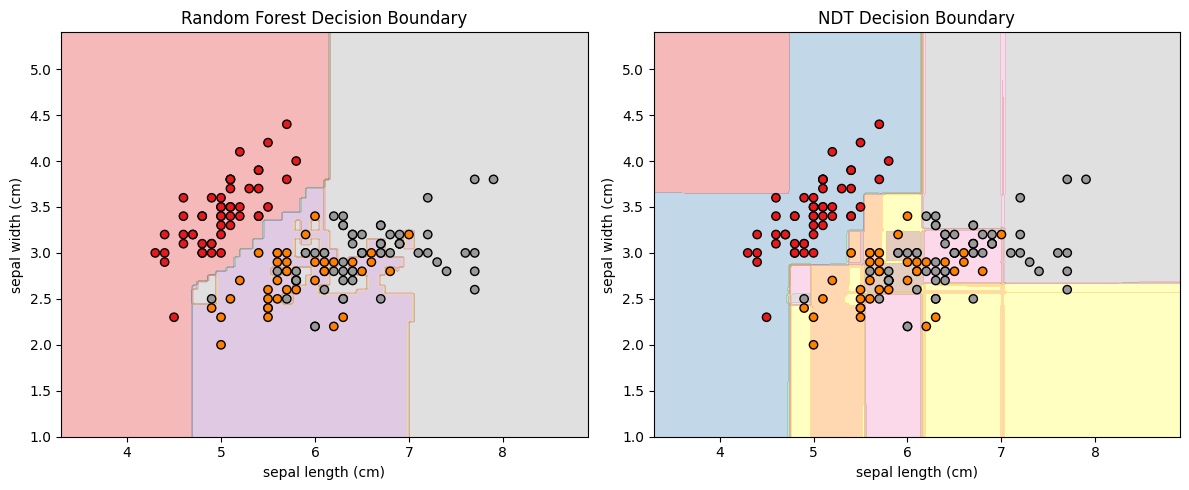

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Pour la visualisation, on prend seulement 2 features
X_vis = X[:, :2]
feature_names_vis = iris.feature_names[:2]

# Split sur les 2 features
X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(X_vis, y, random_state=42)

# Entraîner Random Forest sur 2 features
rf_vis = RandomForestClassifier(random_state=42)
rf_vis.fit(X_train_vis, y_train_vis)

# Entraîner NDT sur 2 features
model_classifier_vis = NDTRegressorWrapper(D=2)
model_classifier_vis.fit(X_train_vis, y_train_vis)

# Grille pour visualiser les frontières
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

# Prédictions sur la grille
Z_rf = rf_vis.predict(grid).reshape(xx.shape)
Z_ndt = model_classifier_vis.predict(grid).reshape(xx.shape)

# Affichage
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z_rf, alpha=0.3, cmap=plt.cm.Set1)
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y, edgecolor='k', cmap=plt.cm.Set1)
plt.title('Random Forest Decision Boundary')
plt.xlabel(feature_names_vis[0])
plt.ylabel(feature_names_vis[1])

plt.subplot(1, 2, 2)
plt.contourf(xx, yy, Z_ndt, alpha=0.3, cmap=plt.cm.Set1)
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y, edgecolor='k', cmap=plt.cm.Set1)
plt.title('NDT Decision Boundary')
plt.xlabel(feature_names_vis[0])
plt.ylabel(feature_names_vis[1])

plt.tight_layout()
plt.show()

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


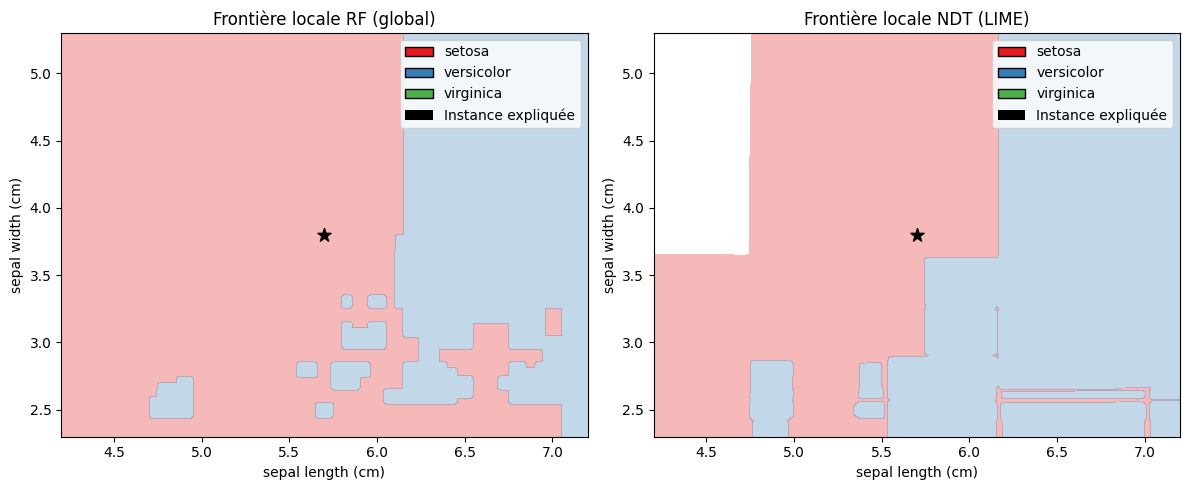

In [12]:
# Visualisation locale continue : frontières RF vs NDT local (LIME) autour d'une instance, avec légende des classes et couleurs cohérentes
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

instance = X_test[1][:2]  # On prend les 2 premières features pour la visualisation
radius = 1.5
n_grid = 200
x_min, x_max = instance[0] - radius, instance[0] + radius
y_min, y_max = instance[1] - radius, instance[1] + radius
xx, yy = np.meshgrid(np.linspace(x_min, x_max, n_grid), np.linspace(y_min, y_max, n_grid))
grid = np.c_[xx.ravel(), yy.ravel()]

# Prédiction du modèle global (Random Forest) sur la grille
rf_preds = rf_vis.predict(grid).reshape(xx.shape)

# Prédiction du modèle local (NDT entraîné par LIME) sur la grille
ndt_preds = model_classifier_vis.predict(grid).reshape(xx.shape)

# Couleurs fixes pour chaque classe
n_classes = len(iris.target_names)
cmap = ListedColormap([plt.cm.Set1(i) for i in range(n_classes)])
bounds = list(range(n_classes + 1))

legend_elements = [Patch(facecolor=cmap(i), edgecolor='k', label=iris.target_names[i]) for i in range(n_classes)]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
contour1 = plt.contourf(xx, yy, rf_preds, levels=bounds, cmap=cmap, alpha=0.3)
plt.scatter(instance[0], instance[1], c='black', s=100, marker='*', label='Instance expliquée')
plt.xlabel(feature_names_vis[0])
plt.ylabel(feature_names_vis[1])
plt.title("Frontière locale RF (global)")
plt.legend(handles=legend_elements + [Patch(facecolor='black', label='Instance expliquée')])

plt.subplot(1, 2, 2)
contour2 = plt.contourf(xx, yy, ndt_preds, levels=bounds, cmap=cmap, alpha=0.3)
plt.scatter(instance[0], instance[1], c='black', s=100, marker='*', label='Instance expliquée')
plt.xlabel(feature_names_vis[0])
plt.ylabel(feature_names_vis[1])
plt.title("Frontière locale NDT (LIME)")
plt.legend(handles=legend_elements + [Patch(facecolor='black', label='Instance expliquée')])

plt.tight_layout()
plt.show()

c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


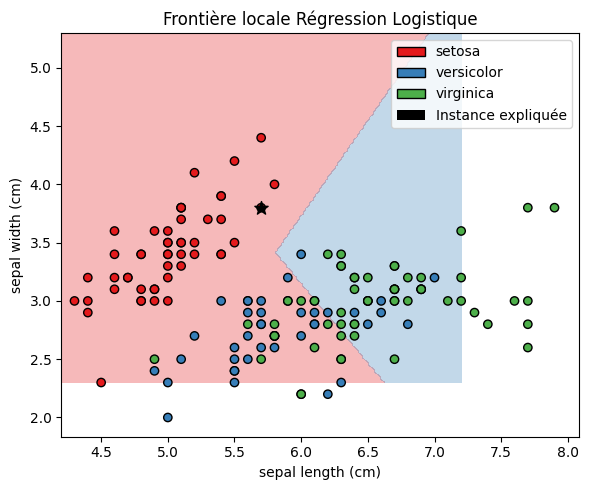

In [13]:
# Visualisation locale : frontière d'une régression logistique (pour comparaison)
from sklearn.linear_model import LogisticRegression

# Entraîner une régression logistique sur les 2 features
logreg = LogisticRegression(multi_class='auto', solver='lbfgs')
logreg.fit(X_train_vis, y_train_vis)

# Prédiction sur la même grille
logreg_preds = logreg.predict(grid).reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, logreg_preds, levels=bounds, cmap=cmap, alpha=0.3)
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y, edgecolor='k', cmap=cmap)
plt.scatter(instance[0], instance[1], c='black', s=100, marker='*', label='Instance expliquée')
plt.xlabel(feature_names_vis[0])
plt.ylabel(feature_names_vis[1])
plt.title("Frontière locale Régression Logistique")
plt.legend(handles=legend_elements + [Patch(facecolor='black', label='Instance expliquée')])
plt.tight_layout()
plt.show()

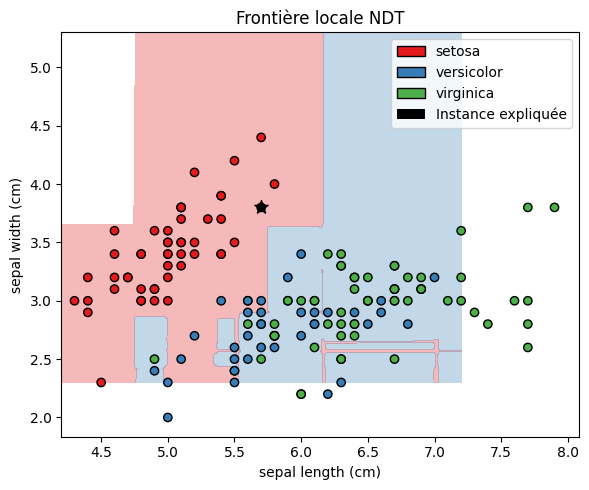

In [14]:
# Visualisation locale : frontière de la NDT sur les 2 features (pour comparaison)
plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, ndt_preds, levels=bounds, cmap=cmap, alpha=0.3)
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y, edgecolor='k', cmap=cmap)
plt.scatter(instance[0], instance[1], c='black', s=100, marker='*', label='Instance expliquée')
plt.xlabel(feature_names_vis[0])
plt.ylabel(feature_names_vis[1])
plt.title("Frontière locale NDT")
plt.legend(handles=legend_elements + [Patch(facecolor='black', label='Instance expliquée')])
plt.tight_layout()
plt.show()

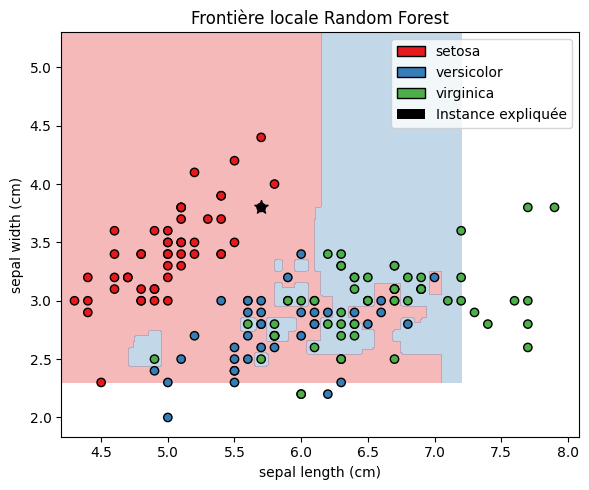

In [15]:
# Visualisation locale : frontière du Random Forest sur les 2 features (pour comparaison)
plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, rf_preds, levels=bounds, cmap=cmap, alpha=0.3)
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y, edgecolor='k', cmap=cmap)
plt.scatter(instance[0], instance[1], c='black', s=100, marker='*', label='Instance expliquée')
plt.xlabel(feature_names_vis[0])
plt.ylabel(feature_names_vis[1])
plt.title("Frontière locale Random Forest")
plt.legend(handles=legend_elements + [Patch(facecolor='black', label='Instance expliquée')])
plt.tight_layout()
plt.show()

c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


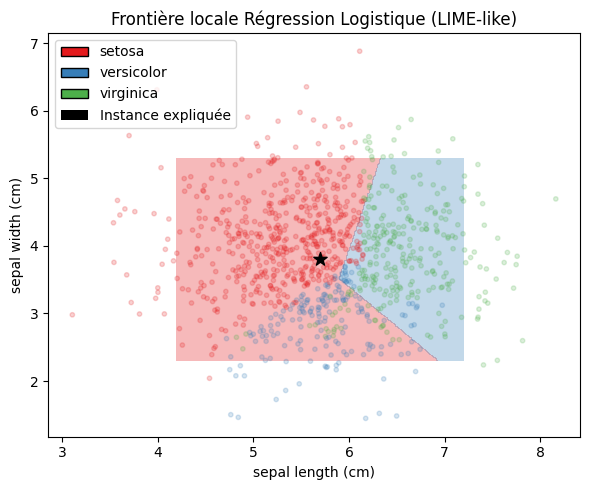

In [16]:
# Visualisation locale : frontière d'une régression logistique locale (LIME-like) autour de l'instance
from sklearn.linear_model import LogisticRegression

# Générer des perturbations autour de l'instance expliquée
n_perturb = 1000
np.random.seed(42)
perturb = instance + np.random.normal(0, 0.8, size=(n_perturb, 2))
# Labels des perturbations selon le modèle global
perturb_labels = rf_vis.predict(perturb)

# Entraîner la régression logistique locale
logreg_local = LogisticRegression(multi_class='auto', solver='lbfgs')
logreg_local.fit(perturb, perturb_labels)

# Prédiction sur la grille locale
logreg_local_preds = logreg_local.predict(grid).reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, logreg_local_preds, levels=bounds, cmap=cmap, alpha=0.3)
plt.scatter(perturb[:, 0], perturb[:, 1], c=perturb_labels, cmap=cmap, alpha=0.2, s=10, label='Perturbations')
plt.scatter(instance[0], instance[1], c='black', s=100, marker='*', label='Instance expliquée')
plt.xlabel(feature_names_vis[0])
plt.ylabel(feature_names_vis[1])
plt.title("Frontière locale Régression Logistique (LIME-like)")
plt.legend(handles=legend_elements + [Patch(facecolor='black', label='Instance expliquée')])
plt.tight_layout()
plt.show()